<a href="https://colab.research.google.com/github/Praj24-04/Machine-Learning/blob/main/MLPrac8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

#Synthetic customer data with 200 records that includes demographic and purchase information.

In [ ]:
np.random.seed(42)

data = {
    "Age": np.random.randint(18, 60, 200),
    "Income": np.random.randint(20000, 100000, 200),
    "Purchase_Amount": np.random.randint(500, 10000, 200),
    "Gender": np.random.choice(["Male", "Female"], 200),
    "Membership": np.random.choice(["Yes", "No"], 200)
}

df = pd.DataFrame(data)

In [ ]:
df["Response"] = (
    (df["Income"] > 50000) &
    (df["Membership"] == "Yes") &
    (df["Purchase_Amount"] > 3000)
).astype(int)

df.head()

,Age,Income,Purchase_Amount,Gender,Membership,Response
0,56,45342,4570,Female,No,0
1,46,57157,1080,Male,No,0
2,32,87863,7504,Female,No,0
3,25,72083,8630,Female,No,0
4,38,85733,3647,Female,No,0


# Categorical variables into numeric form

In [ ]:
le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])
df["Membership"] = le.fit_transform(df["Membership"])

# Separating input features (X) and target variable (y).

In [ ]:
X = df.drop("Response", axis=1)
y = df["Response"]

# Spliting dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Training Logistic Regression model to predict customer response

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Classification results.

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[22  6]
 [ 5  7]]


#Graphical Representation

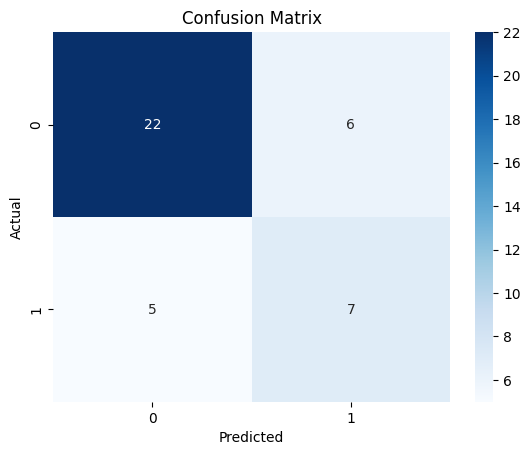

In [ ]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#Overall correctness of the model

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.725


# Positive responses that are correct.

In [ ]:
print("Precision:", precision_score(y_test, y_pred))

Precision: 0.5384615384615384


In [ ]:
print("Recall:", recall_score(y_test, y_pred))

Recall: 0.5833333333333334


# Provides balance between precision and recall

In [ ]:
print("F1 Score:", f1_score(y_test, y_pred))

F1 Score: 0.56
